# RL Masterclass - Traditional vs Recurrent Modeling of Behavior

This notebook uses the Azulejos dataset to analyze learning behavior in bandit tasks with two model families: classical reinforcement-learning models and recurrent neural networks.

The idea is to play around with the trade-off between:
- fit: how well the model matches human behavior
- interpretability: how clearly we can explain what the model is doing

Participants are encouraged to explore the data, fit simple baseline models, and then improve or extend them to answer their own research interests. 


### Important Notes for Easy Hacking:
- If you attended Sarah's workshop on Tuesday, you can download and extract the Azulejos data from your drive into a target folder (e.g., "/OSF").
- Don't worry too much about the DataManager (DM), it handles loading and formatting (for different model requirements), but it also contains a df that can be modified as desired (DM.df). You can also ditch the DM completely if you prefer to just work with the df later. 
- When / if implementing classes / extending ModelInterface to create your own model variant, you should do that inside the notebook to not have to restart the kernel.

## Contents

1. Theory: computational models of behavior
2. The Azulejos Data (in brief)
3. Hack Pipeline and Helpers
   1. DataManager: Data Loading and Formatting
   2. Data inspection: task structure, heterogeneity, and behavior
   3. Learning curves: descriptive summary of learning across task settings
   4. Classical model: Rescorla-Wagner baseline and parameter interpretation
   5. Recurrent model: simple RNN baseline
   6. Comparison: fit, generalization, and interpretability
4. Suggestions for your hack


## 1. Theory: Using computational models of cognition

Computational models help us move from description to explanation.

- They force us to state explicit assumptions about how behavior is generated.
- They let us test hypotheses quantitatively against real trial-by-trial data.
- They allow simulation, so we can ask whether a model reproduces key behavioral patterns.

So, while we do care about accurate model fit, we also care about whether a model provides the most useful scientific explanation.


This section is a compact refresher and can be skimmed if you are already familiar with the concepts.

### 1.1 Classical reinforcement learning (Rescorla-Wagner)

Rescorla-Wagner assumes that people update action values through prediction errors.

- Prediction error: $\delta_t = R_t - Q_t(A_t)$
  - where $R_t$ is the reward received at trial $t$, and $Q_t(A_t)$ is the expected value of the chosen action.
- Value update: $Q_{t+1}(A_t) = Q_t(A_t) + \alpha\,\delta_t$
- Action probabilities: $P(A_t=a) = \frac{\exp(\beta Q_t(a))}{\sum_i \exp(\beta Q_t(i))}$

Interpretation:
- $\alpha$ controls learning speed.
- $\beta$ controls exploration vs. exploitation.

Strengths:
- Interpretable parameters.
- Data-efficient fitting.

Limitations:
- Strong assumptions about learning dynamics.
- Limited flexibility for complex sequential patterns.

### 1.2 Recurrent neural networks

RNNs learn sequence-to-action mappings directly from data, without hand-coded learning rules.

- Hidden state update: $h_t = f(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$
  - where $h_t$ is the hidden state at time $t$, $x_t$ is the input (e.g., previous action and reward), and $f$ is a non-linear activation function (e.g., tanh or ReLU).
  - $W_{xh}$, $W_{hh}$ (the transition matrices), and $b_h$ are learnable parameters.
- Action probabilities: $P(A_t) = \mathrm{Softmax}(W_{hy}h_t + b_y)$

Strengths:
- High flexibility and memory for longer-range dependencies.
- Often strong predictive performance when enough data are available.

Limitations:
- Harder to interpret mechanistically.
- Usually needs more data and tuning than classical models.


## 2. The Azulejos Dataset

The Azulejos dataset contains many bandit-learning tasks. Each task is a short reinforcement-learning environment in which participants choose among a set of actions and receive feedback. The important point is that not all tasks are identical:

- some tasks have different numbers of actions and states
- some tasks are deterministic and some are probabilistic
- some vary in how information is displayed or how blocks change over time
- some are easier to learn than others

Thanks to it's variability, the data lets us ask whether human behavior changes in systematic ways across task conditions, and whether simple models explain those changes or whether richer models are required.

Check out Sarah Master's slides or Workshop notebook for more details on the dataset and task structure.


## 3. Hack Pipeline and Materials

The following sections provide materials and helper functions for your hack. They also outline a short workflow for exploring the data and two basic models that can be used to fit and understand it. We think that this will be very useful in pursuing your research interest, but, of course, you can also ignore them completely. 

The workflow is:
1. loading local data (if available) and formatting
2. inspecting task structure and session examples
3. summarizing behavior with learning curves
4. fitting and analyzing a classical baseline model
5. fitting and analyzing a compact recurrent baseline
6. comparing fit and interpretability with matched evaluation


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

### 3.1 DataManager

`DataManager` is the main data interface used in this notebook.

It's a class that loads local Azulejos files, organizes task/session information, and provides sequence formats for both classical and recurrent models. It is basically a wrapper for a classic pandas `df`, which you can modify and re-assign as usual. The first workflow step first checks if data is locally available, then summarizes.


In [2]:
from DataManager import DataManager

# search common local folders for azulejos csv files. Add yours to the list if you have the data loaded.
candidate_dirs = [
    Path.cwd() / "data" / "OSF",
    Path.cwd() / "azulejos_data",
    Path.cwd() / "OSF",
]

local_data_dir = None
for folder in candidate_dirs:
    csv_files = sorted(folder.glob("*.csv"))  # collect csv candidates in this folder
    if csv_files:
        local_data_dir = str(folder)
        break

if local_data_dir is None:
    print("No local Azulejos CSV files were found.")
    print("Please place the data in one of the following folders and rerun this cell:")
    for folder in candidate_dirs:
        print(f"  - {folder}")
    local_data_dir = str(candidate_dirs[0])  # default to first candidate folder
    print(f"Defaulting to first candidate folder: {local_data_dir}\nIMPORTANT: Specify a download limit to attempt loading OSF data directly (might be slow).")


print(f"Using local dataset directory: {local_data_dir}")
DM = DataManager(data_dir=local_data_dir, download_limit=10)  # parse local files into model-ready structures, will download only if not locally available


Using local dataset directory: c:\Users\malte\Documents\iiccsss\hacks\rl_behavioral_modeling\OSF
Local data found with 400 files. Skipping OSF download.
Formatting data for models...


100%|██████████| 400/400 [01:54<00:00,  3.49it/s]


### 3.2 Inspection of the Data Structure

In [4]:
# inspect dataset structure before modeling.
# retrieve high-level dataset description.
summary = DM.get_dataset_description()
print("Dataset overview:")
for key, value in summary.items():
    if isinstance(value, list):
        print(f"  {key}: {len(value)} entries")
    else:
        print(f"  {key}: {value}")

# summarize number of tasks per family.
feature_summary = (
    DM.df[["task_id", "task_type", "n_actions"]]
    .drop_duplicates()  # keep one metadata row per task
    .groupby("task_type")
    .agg(n_tasks=("task_id", "nunique"), n_actions=("n_actions", "first"))  # aggregate family counts
    .reset_index()
)
print("\nTask families in the dataset:")
print(feature_summary)

# inspect one representative session record.
example_row = DM.df.iloc[0]
print("\nExample session:")
print(f"  subject_id: {example_row['subject_id']}")
print(f"  task_id: {example_row['task_id']}")
print(f"  task_type: {example_row['task_type']}")
print(f"  n_actions: {example_row['n_actions']}")
print(f"  first 12 actions: {example_row['actions'][:12].tolist()}")
print(f"  first 12 rewards: {example_row['rewards'][:12].tolist()}")

# select one task for downstream model fitting.
task_ids_sorted = sorted(summary["task_ids"])
selected_task = task_ids_sorted[0]
print(f"\nSelected task for the demo: {selected_task} (first task_id in sorted order)")

Dataset overview:
  n_subjects: 376
  n_tasks: 1397
  n_trials: 395085
  task_ids: 1397 entries
  task_types: 4 entries
  subject_ids: 376 entries

Task families in the dataset:
              task_type  n_tasks  n_actions
0               actions       98          6
1                states      448          3
2    states_and_actions      422          2
3  states_times_actions      429          4

Example session:
  subject_id: 1688
  task_id: task_5.0_run_1
  task_type: actions
  n_actions: 6
  first 12 actions: [0, 1, 3, 4, 4, 5, 0, 1, 2, 3, 4, 4]
  first 12 rewards: [0.0, 20.0, 0.0, 52.0, 35.0, 0.0, 0.0, 29.0, 0.0, 0.0, 28.0, 28.0]

Selected task for the demo: task_1.0_run_1 (first task_id in sorted order)


In [5]:
# you can also index the DM's df directly to inspect the data (and filter and stuff)
DM.df.head()

,subject_id,task_id,task_type,n_actions,actions,rewards,best_actions,action_reward_probs,X,Y
0,1688,task_5.0_run_1,actions,6,"[0, 1, 3, 4, 4, 5, 0, 1, 2, 3, 4, 4, 4, 4, 4, ...","[0.0, 20.0, 0.0, 52.0, 35.0, 0.0, 0.0, 29.0, 0...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.0, 58.625, 0.0, 0.0, 45.869565217391305, 0.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[0, 1, 3, 4, 4, 5, 0, 1, 2, 3, 4, 4, 4, 4, 4, ..."
1,1688,task_5694.0_run_2,states,3,"[0, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 2, ...","[0.0, 0.0, 0.0, 77.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[2, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, ...","[9.662790697674419, 41.69230769230769, 45.3409...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[0, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 2, ..."
2,1688,task_3565.0_run_3,states_times_actions,4,"[3, 2, 1, 0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0.0, 54.0, 0.0, 0.0, 0.0, 54.0, 55.0, 50.0, 4...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[31.885714285714286, 26.586206896551722, 50.43...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[3, 2, 1, 0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ..."
3,1688,task_4.0_run_4,actions,2,"[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...","[0.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[5.882352941176471, 66.66666666666667]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0,...","[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ..."
4,1688,task_2975.0_run_5,states,4,"[0, 0, 3, 3, 1, 2, 3, 2, 3, 0, 2, 2, 2, 1, 3, ...","[0.0, 0.0, 39.0, 44.0, 0.0, 60.0, 43.0, 0.0, 0...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[17.157894736842106, 30.458333333333332, 27.01...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[0, 0, 3, 3, 1, 2, 3, 2, 3, 0, 2, 2, 2, 1, 3, ..."


In [6]:
# inspect one selected task in detail.
task_props = DM.get_task_properties(task_id=selected_task)
print(f"\nTask properties for {selected_task}:")
for key, value in task_props.items():
    print(f"  {key}: {value}")



Task properties for task_1.0_run_1:
  task_type: states
  n_actions: 3
  n_trials: 200
  action_reward_probs: [81.3559322  42.85714286 84.03361345]


In [7]:
# summarize number of sessions per task.
all_tasks_summary = DM.df['task_id'].value_counts().reset_index()  # count sessions by task_id
all_tasks_summary.columns = ['task_id', 'n_sessions']
print(all_tasks_summary.head())
print(f"\nSelected demo task: {selected_task}")
print(f"Sessions for the demo task: {all_tasks_summary.loc[all_tasks_summary['task_id'] == selected_task, 'n_sessions'].iloc[0]}")


          task_id  n_sessions
0  task_6.0_run_5          32
1  task_4.0_run_4          27
2  task_2.0_run_1          27
3  task_3.0_run_3          26
4  task_6.0_run_2          25

Selected demo task: task_1.0_run_1
Sessions for the demo task: 18


### 3.3 Visualization of Learning Curves

For data inspection and visualizing learning curves over 1 feature of the data (e.g., `task_type`). 

In [8]:
# analyze learning curves from best-action choices.

def session_learning_curve(session_row, max_trials=None):
    actions = np.asarray(session_row["actions"], dtype=int)
    best_actions = np.asarray(session_row.get("best_actions", []), dtype=int)

    if best_actions.size == 0:
        action_reward_probs = np.asarray(session_row["action_reward_probs"], dtype=float)
        fallback_best_action = int(np.argmax(action_reward_probs))
        best_actions = np.full(len(actions), fallback_best_action, dtype=int)

    n_trials = min(len(actions), len(best_actions))
    actions = actions[:n_trials]
    best_actions = best_actions[:n_trials]

    if max_trials is not None:
        actions = actions[:max_trials]
        best_actions = best_actions[:max_trials]

    return np.asarray(actions == best_actions, dtype=float)


def pull_average_learning_curve(curves, max_trials=None):
    if not curves:
        return np.array([]), np.array([]), 0

    max_len = max(len(curve) for curve in curves)
    if max_trials is not None:
        max_len = min(max_len, max_trials)

    padded = []
    for curve in curves:
        curve = np.asarray(curve, dtype=float)[:max_len]
        padded_curve = np.concatenate([curve, np.full(max_len - len(curve), np.nan)])  # pad for equal length averaging
        padded.append(padded_curve)

    arr = np.asarray(padded, dtype=float)
    mean_curve = np.nanmean(arr, axis=0)  # ignore padded nans
    se_curve = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))  # standard error per trial
    return mean_curve, se_curve, max_len


def plot_learning_curve_by_task_type(feature_name="task_type", max_trials=20):
    _, ax = plt.subplots(figsize=(10, 5))

    for label, group in DM.df.groupby(feature_name):  # split sessions by task-level feature
        curves = [session_learning_curve(row, max_trials=max_trials) for _, row in group.iterrows()]
        if len(curves) == 0:
            continue

        mean_curve, se_curve, _ = pull_average_learning_curve(curves, max_trials=max_trials)
        x = np.arange(len(mean_curve))
        ax.errorbar(x, mean_curve, yerr=se_curve, label=str(label), fmt='-o', capsize=4)  # plot mean with standard error bars

    ax.set_xlabel('Trial')
    ax.set_ylabel('Proportion of best actions')
    ax.set_title(f'Mean learning curve by {feature_name}')
    ax.legend()
    plt.tight_layout()
    plt.show()


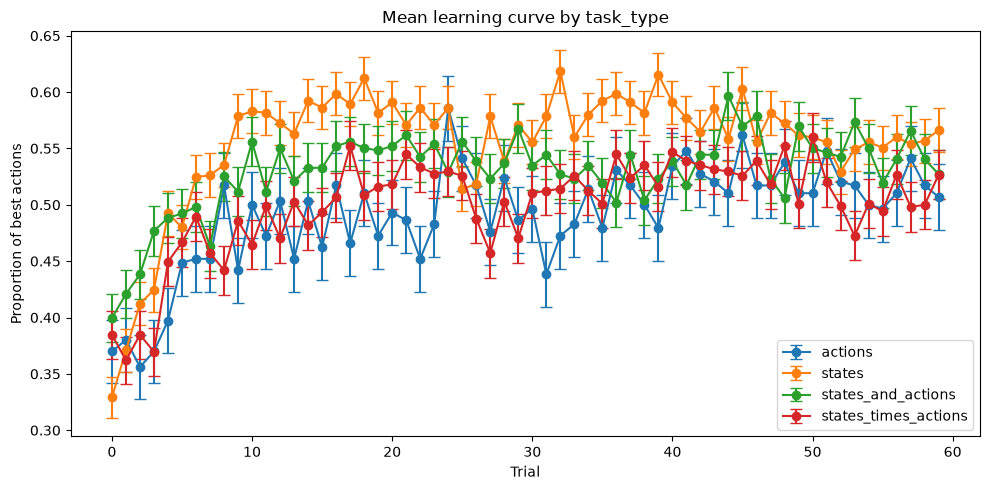

In [9]:
# plot descriptive learning curves across task families.
plot_learning_curve_by_task_type(feature_name='task_type', max_trials=60)

Feel free to experiment with this function and apply it to different features or subsets of the data. Note that, with a lot of data, plotting might become messy if you choose to (e.g.,) compare all `task_id` values.

### 3.4 Fitting a Classical RL Model

Here we introduce a simple Rescorla-Wagner model and fit it to the data. The model is implemented as a class that inherits from `ModelInterface`, which provides a standard interface for fitting and evaluating models. If you check out the implementation inside the `Model_RescorlaWagner` class, you will see that it is a simple implementation of the Rescorla-Wagner model with a softmax action selection rule, just like we describe in section 1.1.

In [10]:
# classical modeling: rescorla-wagner baseline

from Model_RescorlaWagner import RescorlaWagnerModel

print(f"Modeling task: {selected_task}")

task_properties = DM.get_task_properties(selected_task)
print(f"Task properties for {selected_task}:")
for key, value in task_properties.items():
    print(f"  {key}: {value}")

# initialize and inspect model metadata.
rw_model = RescorlaWagnerModel(task_properties)
print("\nModel description:")
for key, value in rw_model.get_model_description().items():
    print(f"  {key}: {value}")


Modeling task: task_1.0_run_1
Task properties for task_1.0_run_1:
  task_type: states
  n_actions: 3
  n_trials: 200
  action_reward_probs: [81.3559322  42.85714286 84.03361345]

Model description:
  name: RescorlaWagnerModel
  fitted_status: Unfitted
  description: Standard Rescorla-Wagner model with Softmax choice.
  n_parameters: 2
  latent_shape: N/A
  parameters: Unfitted


In [11]:
# we get action-reward sequence for all subjects who completed this task
actions, rewards = DM.get_human_data(task_id=selected_task)

# fit one session-level model to inspect latent dynamics directly.
subj_idx = 0 # note that this does not refer to a 'subject_0', but takes the data of the first subject who completed this task
subject_actions = actions[subj_idx]
subject_rewards = rewards[subj_idx]
subject_model = RescorlaWagnerModel(task_properties)
subject_model.fit([subject_actions], [subject_rewards])  # single-session fit for latent-state visualization

# refresh latent states with a post-fit forward pass using final parameters.
_ = subject_model.get_action_probabilities(subject_actions, subject_rewards)
q_history = subject_model.get_latent_states()
print(f"\nLatent Q-values for a representative subject have shape: {q_history.shape}")
print("First 10 trials:")
print(np.round(q_history[:10], 3))

Fit successful! Alpha: 0.113, Beta: 0.029; NLL: 168.673

Latent Q-values for a representative subject have shape: (200, 3)
First 10 trials:
[[ 0.5    0.5    0.5  ]
 [ 0.5    0.5    0.443]
 [ 0.5    0.443  0.443]
 [ 0.5    0.393  0.443]
 [ 0.5    0.393  0.393]
 [11.753  0.393  0.393]
 [21.734  0.393  0.393]
 [30.586  0.393  0.393]
 [38.436  0.393  0.393]
 [45.399  0.393  0.393]]


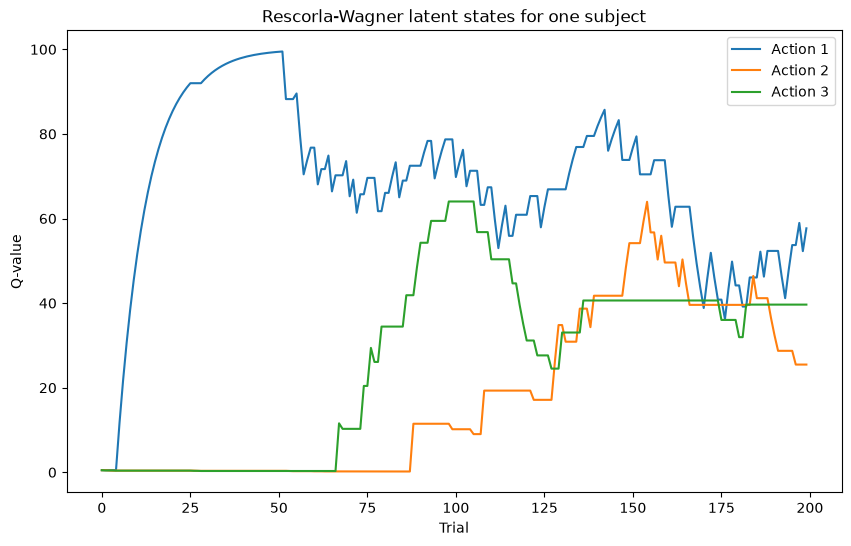

In [12]:
# plot latent q-value trajectories for the session-level fit.
if q_history is not None:
    plt.figure(figsize=(10, 6))
    for action in range(q_history.shape[1]):
        plt.plot(q_history[:, action], label=f'Action {action + 1}')
    plt.xlabel('Trial')
    plt.ylabel('Q-value')
    plt.title('Rescorla-Wagner latent states for one subject')
    plt.legend()
    plt.show()
else:
    print('No latent state history was recorded for this model fit.')


### 3.5 Recurrent Network Baseline

The recurrent baseline provides a higher-capacity alternative to Rescorla-Wagner.

- the classical model encodes explicit assumptions about learning dynamics
- the recurrent model learns sequence-to-choice mappings directly from data
- this often changes predictive fit and reduces direct interpretability

The comparison is evaluated with common train/test splits and metrics.


In [13]:
# preview tensor-formatted data used by recurrent models.
X_train, X_test, Y_train, Y_test = DM.get_tensor_data(tasks_subset=[selected_task])  # split sessions into train/test tensors
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

# (this is just a preview of the data format)


X_train shape: (15, 193, 23)
X_test shape: (3, 193, 23)
Y_train shape: (15, 193)
Y_test shape: (3, 193)


#### Model implementations (using an Interface)

In this section, we implement and compare the two models that should have the same capabilities:

1. fit on action/reward sequences
2. return trial-by-trial action probabilities
3. generate simulated action/reward sequences
4. expose latent states for interpretation

This allows us to compare models that still differ in flexibility and interpretability (under the 'hood').
If / when you implement your own models, I'd recommend doing so through the ModelInterface, which forces you to implement the `fit` and `get_action_probabilities` methods and automatically provides a `simulate` method. This will facilitate evaluation and comparison later. Implement the class inside this notebook so that you won't have to restart the kernel when updating your code.

#### Model Comparison Setup (and Dilemma)

To compare models "fairly", we use the same selected task and the same session-level train/test split. Note that, usually, classical and RNN models are NOT fitted on the same amount / quality of data, since they have different requirements and use cases. This is what we want to highlight here.

- Both models are fit on the same training sessions.
- Both are evaluated on the same held-out sessions.
- Held-out comparison uses NLL and pseudo-R2.
- AIC/BIC are reported on training-fit likelihood (complexity-penalized fit), not on held-out rows.

This way, differences in fit are less likely to reflect data leakage or mismatched evaluation, but show differences in the models true capabilities (of fittign the given data)

After fitting both models, we compare behavior on held-out sessions using replay-based best-action metrics.

We will plot three curves together:
1. Human held-out best-action rate
2. Rescorla-Wagner expected probability of the held-out best action
3. RNN expected probability of the held-out best action

This avoids introducing a synthetic reward environment for the main baseline comparison.

In [14]:
from Model_RNN import SimpleRNNModel

# fit rw and rnn on the same session split.
rng = np.random.default_rng(GLOBAL_SEED)
indices = np.arange(len(actions))
rng.shuffle(indices)  # shuffle session indices before splitting

test_size = max(1, int(0.2 * len(indices)))  # reserve 20% for held-out evaluation
test_idx = indices[:test_size]
train_idx = indices[test_size:]

if len(train_idx) == 0:
    train_idx = indices
    test_idx = indices

train_actions = [actions[i] for i in train_idx]
train_rewards = [rewards[i] for i in train_idx]
test_actions = [actions[i] for i in test_idx]
test_rewards = [rewards[i] for i in test_idx]

selected_task_rows = DM.df[DM.df["task_id"] == selected_task].reset_index(drop=True)
if len(selected_task_rows) != len(actions):
    raise ValueError("Mismatch between selected_task rows and sequential action/reward lists.")

train_rows = selected_task_rows.iloc[train_idx].reset_index(drop=True)
test_rows = selected_task_rows.iloc[test_idx].reset_index(drop=True)

print(f"Train sessions: {len(train_actions)} | Test sessions: {len(test_actions)}")
print(f"Split seed: {GLOBAL_SEED}")

# compare RW and RNN models on the same train/test split.
rw_comparison_model = RescorlaWagnerModel(task_properties)
rnn_comparison_model = SimpleRNNModel(task_properties, hidden_size=16, 
                                      learning_rate=0.05, n_epochs=40, 
                                      seed=GLOBAL_SEED)

rw_comparison_model.fit(train_actions, train_rewards)
rnn_comparison_model.fit(train_actions, train_rewards)

rw_test_probs = rw_comparison_model.get_action_probabilities(test_actions[0], test_rewards[0])
rnn_test_probs = rnn_comparison_model.get_action_probabilities(test_actions[0], test_rewards[0])

print("\nProbability output sanity check on one held-out session:")
print(f"RW probs shape: {rw_test_probs.shape}")
print(f"RNN probs shape: {rnn_test_probs.shape}")
print(f"RW row-sum (trial 1): {rw_test_probs[0].sum():.3f}")
print(f"RNN row-sum (trial 1): {rnn_test_probs[0].sum():.3f}")

Train sessions: 15 | Test sessions: 3
Split seed: 42
Fit successful! Alpha: 0.374, Beta: 0.027; NLL: 2647.268


KeyboardInterrupt: 

#### Evaluation and interpretation

At this stage, we compare models on two accounts:

1. Predictive fit and generalization (held-out NLL, held-out pseudo-R2)
2. Complexity-aware in-sample fit (train AIC/BIC)

Interpretability remains a separate scientific criterion (for example, parameter meaning and latent-state transparency).

In [ ]:
def evaluate_model_on_sessions(model, actions_list, rewards_list, include_complexity_penalty=False):
    epsilon = 1e-8
    total_nll = 0.0
    total_trials = 0

	# compute negative log-likelihood (NLL) across all sessions
    for acts, rews in zip(actions_list, rewards_list):
        probs = model.get_action_probabilities(acts, rews)
        chosen_probs = probs[np.arange(len(acts)), np.asarray(acts, dtype=int)]  # select probability assigned to observed action
        chosen_probs = np.clip(chosen_probs, epsilon, 1.0)  # avoid log(0) in likelihood computation
        total_nll += -np.sum(np.log(chosen_probs))
        total_trials += len(acts)

	# compute model complexity penalties (AIC/BIC) if requested
    k = model.get_num_parameters()
    aic = np.nan
    bic = np.nan
    if include_complexity_penalty:
        aic = 2 * k + 2 * total_nll
        bic = k * np.log(max(total_trials, 1)) + 2 * total_nll

    random_nll = -total_trials * np.log(1.0 / model.n_actions)
    pseudo_r2 = 1 - (total_nll / random_nll) if random_nll > 0 else np.nan

    return {
        "NLL": total_nll,
        "AIC": aic,
        "BIC": bic,
        "Pseudo-R2": pseudo_r2,
        "n_params": k,
        "n_trials": total_trials,
    }

# evaluate both models on train and test sets, including complexity penalties for train metrics only
rw_train_metrics = evaluate_model_on_sessions(rw_comparison_model, train_actions, train_rewards, include_complexity_penalty=True)
rnn_train_metrics = evaluate_model_on_sessions(rnn_comparison_model, train_actions, train_rewards, include_complexity_penalty=True)
rw_test_metrics = evaluate_model_on_sessions(rw_comparison_model, test_actions, test_rewards, include_complexity_penalty=False)
rnn_test_metrics = evaluate_model_on_sessions(rnn_comparison_model, test_actions, test_rewards, include_complexity_penalty=False)

comparison_df = pd.DataFrame([
    {"model": "Rescorla-Wagner", "eval_set": "train", **rw_train_metrics},
    {"model": "Rescorla-Wagner", "eval_set": "test", **rw_test_metrics},
    {"model": "Simple RNN", "eval_set": "train", **rnn_train_metrics},
    {"model": "Simple RNN", "eval_set": "test", **rnn_test_metrics},
])

print("Train/Test fit comparison (AIC/BIC shown for train rows only):")
print(comparison_df[["model", "eval_set", "NLL", "AIC", "BIC", "Pseudo-R2", "n_params", "n_trials"]])

Train/Test fit comparison (AIC/BIC shown for train rows only):
             model eval_set          NLL          AIC          BIC  Pseudo-R2  \
0  Rescorla-Wagner    train  2647.268351  5298.536701  5310.544764   0.194906   
1  Rescorla-Wagner     test   471.126365          NaN          NaN   0.284077   
2       Simple RNN    train  3284.284912  7342.569824  9666.130018   0.001174   
3       Simple RNN     test   659.917908          NaN          NaN  -0.002810   

   n_params  n_trials  
0         2      2993  
1         2       599  
2       387      2993  
3       387       599  


#### Interpretation of baseline fit results

In many runs, Rescorla-Wagner can remain competitive or better on held-out prediction despite far fewer parameters, but this can vary by task and split.

This baseline uses a relatively small amount of training data (single task with a session-level split), which is often not the setting where recurrent models show their full advantage.

In your hack, you might want to explore this difference, finding out where RNNs produce a better fit than RW models. 

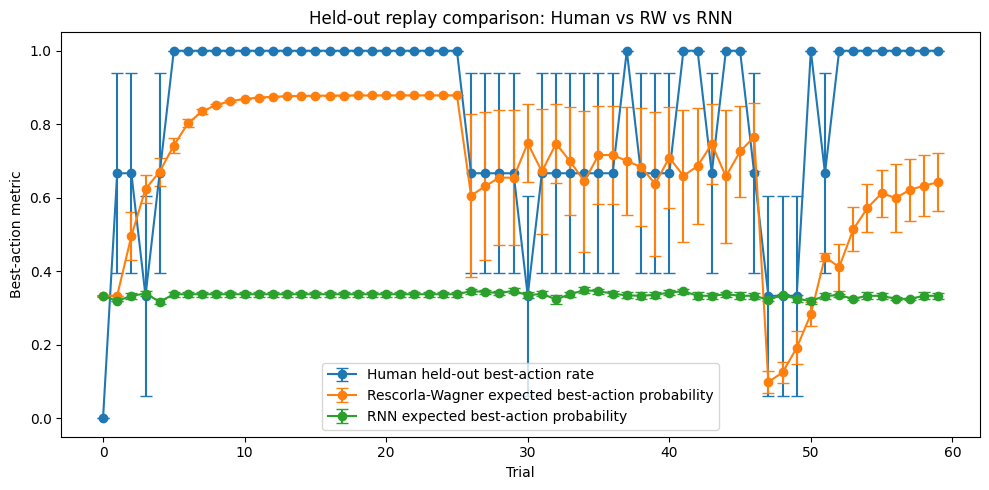

Held-out sessions used for replay comparison: 3


In [ ]:
def best_action_curve_from_observed_actions(action_sequence, best_action_sequence, max_trials=60):
    actions = np.asarray(action_sequence, dtype=int)
    best_actions = np.asarray(best_action_sequence, dtype=int)
    n = min(len(actions), len(best_actions), max_trials)
    if n == 0:
        return np.array([], dtype=float)
    return np.asarray(actions[:n] == best_actions[:n], dtype=float)


def best_action_prob_curve_from_model(model, action_sequence, reward_sequence, best_action_sequence, max_trials=60):
    probs = model.get_action_probabilities(action_sequence, reward_sequence)
    best_actions = np.asarray(best_action_sequence, dtype=int)
    n = min(probs.shape[0], len(best_actions), max_trials)
    if n == 0:
        return np.array([], dtype=float)
    trial_idx = np.arange(n)
    return np.asarray(probs[trial_idx, best_actions[:n]], dtype=float)


if len(test_rows) != len(test_actions):
    raise ValueError("Mismatch between held-out rows and held-out action sequences.")

human_curves = []
rw_curves = []
rnn_curves = []

for i, (acts, rews) in enumerate(zip(test_actions, test_rewards)):
    best_actions_seq = np.asarray(test_rows.iloc[i]["best_actions"], dtype=int)
    human_curves.append(best_action_curve_from_observed_actions(acts, best_actions_seq, max_trials=60))
    rw_curves.append(best_action_prob_curve_from_model(rw_comparison_model, acts, rews, best_actions_seq, max_trials=60))
    rnn_curves.append(best_action_prob_curve_from_model(rnn_comparison_model, acts, rews, best_actions_seq, max_trials=60))

human_mean, human_se, _ = pull_average_learning_curve(human_curves, max_trials=60)
rw_mean, rw_se, _ = pull_average_learning_curve(rw_curves, max_trials=60)
rnn_mean, rnn_se, _ = pull_average_learning_curve(rnn_curves, max_trials=60)

plt.figure(figsize=(10, 5))
plt.errorbar(np.arange(len(human_mean)), human_mean, yerr=human_se, fmt='-o', capsize=4, label='Human held-out best-action rate')
plt.errorbar(np.arange(len(rw_mean)), rw_mean, yerr=rw_se, fmt='-o', capsize=4, label='Rescorla-Wagner expected best-action probability')
plt.errorbar(np.arange(len(rnn_mean)), rnn_mean, yerr=rnn_se, fmt='-o', capsize=4, label='RNN expected best-action probability')
plt.xlabel('Trial')
plt.ylabel('Best-action metric')
plt.title('Held-out replay comparison: Human vs RW vs RNN')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Held-out sessions used for replay comparison: {len(test_actions)}")

## 4. Suggested Hack Tracks

Below are three valid and complementary ways to build on this notebook.

### Track A: Improve the fit of classical models while staying interpretable
Why this is valuable:
- You keep a direct link between model parameters and cognitive mechanisms.
- You test whether careful model design can close the fit gap without black-box complexity.

Good directions:
1. Add perseveration or choice-kernel terms.
2. Add forgetting or decay in value updates.
3. Fit task-specific parameters (or hierarchical parameter structure across tasks).
4. Compare each extension with RW using held-out NLL and AIC/BIC.

### Track B: Increase interpretability of RNN models
Why this is valuable:
- RNNs can fit rich behavior, but hidden states are hard to explain.
- Improving interpretability makes high-capacity models scientifically more useful.

Good directions:
1. Relate hidden-state dimensions to known behavioral summaries (for example stay/switch patterns).
2. Use low-dimensional projections and probe classifiers to interpret hidden dynamics.
3. Distill the RNN into a smaller symbolic or parametric surrogate model.
4. Compare interpretation gains against any loss in predictive fit.

### Track C: Use models to answer research questions about the dataset
Why this is valuable:
- Models become tools for inference, not just prediction.
- You can test hypotheses about strategy differences across task conditions.

Good directions:
1. Ask which task families are best explained by RW vs RNN.
2. Compare parameter estimates or hidden dynamics across task types.
3. Test whether one model generalizes better to unseen tasks.
4. Formulate one concrete hypothesis and evaluate it with held-out comparisons.

### Practical advice for all tracks
1. Keep the same train/test split and metrics when comparing variants.
2. Prefer one clear hypothesis per experiment.
3. Report both fit and interpretability outcomes, not fit alone.
